# Notebook 04 — Evaluation

Evaluates the LR and GBM T-learners via Qini curve, top-K targeting,
strategy comparison, and decile-level analysis.

**Pipeline position:** fourth notebook. Requires `03_modeling.ipynb`
to have run (uses `data/predictions/*.npy` and the test pickles).

**Outputs:**
- `data/predictions/qini_curve_lr.npz`, `qini_curve_gbm.npz`
- `docs/figures/qini_curve_lr.png`, `qini_curves_comparison.png`
- `docs/figures/strategy_comparison_lr.png`, `decile_lift_chart.png`
- `docs/figures/decile_profile_lr.csv`, `decile_profile_gbm.csv`
- `docs/writeups/04_results.md` (sections 1–3)
- `docs/writeups/topk_lr_results.json`, `lr_vs_gbm_results.json`, `decile_summary.json`

In [1]:
import os
import sys
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
PREDS_DIR = DATA_DIR / "predictions"
FIG_DIR = PROJECT_ROOT / "docs" / "figures"
WRITEUP_DIR = PROJECT_ROOT / "docs" / "writeups"
os.chdir(PROJECT_ROOT)

sys.path.insert(0, str(PROJECT_ROOT))
%load_ext autoreload
%autoreload 2

from src.data_loading import load_processed_data
from src.evaluation.decile import compute_decile_profile

plt.style.use("seaborn-v0_8-darkgrid")

# Load test row_ids (saved Day 8) and the GBM predictions
data = load_processed_data()
row_id_test = data["row_id_test"]
uplift_lr  = np.load(PREDS_DIR / "uplift_lr.npy")
uplift_gbm = np.load(PREDS_DIR / "uplift_gbm.npy")
feature_cols = data["feature_cols"]

print(f"Test rows: {len(row_id_test):,}")
print(f"LR predictions: {uplift_lr.shape}")
print(f"GBM predictions: {uplift_gbm.shape}")

con = duckdb.connect(str(DATA_DIR / "criteo.duckdb"))
print(f"\nConnected. Tables: {[r[0] for r in con.execute('SHOW TABLES').fetchall()]}")

Test rows: 400,000
LR predictions: (400000,)
GBM predictions: (400000,)

Connected. Tables: ['criteo', 'criteo_sample', 'test', 'train']


In [2]:
preds_df = pd.DataFrame({
    "row_id": row_id_test,
    "uplift_lr": uplift_lr,
    "uplift_gbm": uplift_gbm,
})
print(f"Predictions DF: {preds_df.shape}")
print(preds_df.head(3))

# Replace any existing preds table
con.execute("DROP TABLE IF EXISTS preds")
con.register("preds_df_view", preds_df)
con.execute("CREATE TABLE preds AS SELECT * FROM preds_df_view")
con.unregister("preds_df_view")

n_preds = con.execute("SELECT COUNT(*) FROM preds").fetchone()[0]
print(f"\nWrote {n_preds:,} predictions to DuckDB.")

Predictions DF: (400000, 3)
    row_id  uplift_lr  uplift_gbm
0  1169723   0.000159   -0.000147
1   284695   0.000133    0.000049
2   925171   0.000416    0.000372

Wrote 400,000 predictions to DuckDB.


In [3]:
# Confirm test has row_id
test_cols = con.execute("DESCRIBE test").fetchdf()["column_name"].tolist()
print(f"test columns include row_id: {'row_id' in test_cols}")

con.execute("DROP TABLE IF EXISTS test_with_preds")
con.execute("""
    CREATE TABLE test_with_preds AS
    SELECT
        t.*,
        p.uplift_lr,
        p.uplift_gbm
    FROM test t
    JOIN preds p USING (row_id)
""")

n_joined = con.execute("SELECT COUNT(*) FROM test_with_preds").fetchone()[0]
n_test   = con.execute("SELECT COUNT(*) FROM test").fetchone()[0]
print(f"\nJoined rows: {n_joined:,} (test had {n_test:,})")

# Verify no NaN in uplift columns
nan_check = con.execute("""
    SELECT
        SUM(CASE WHEN uplift_lr  IS NULL THEN 1 ELSE 0 END) AS nan_lr,
        SUM(CASE WHEN uplift_gbm IS NULL THEN 1 ELSE 0 END) AS nan_gbm
    FROM test_with_preds
""").fetchone()
print(f"NaN in uplift_lr: {nan_check[0]}, NaN in uplift_gbm: {nan_check[1]}")

assert n_joined == n_test, "Join lost rows — row_id alignment broken!"
assert nan_check == (0, 0), "NaN predictions found — investigate before plotting"

test columns include row_id: True

Joined rows: 400,000 (test had 400,000)
NaN in uplift_lr: 0, NaN in uplift_gbm: 0


In [4]:
decile_gbm = compute_decile_profile(
    con,
    table_name="test_with_preds",
    uplift_col="uplift_gbm",
    feature_cols=feature_cols,
)
decile_gbm.head()

,decile,n,n_treated,n_control,treatment_rate,conversion_rate,visit_rate,mean_uplift_pred,treated_conv_rate,control_conv_rate,...,mean_f4,mean_f5,mean_f6,mean_f7,mean_f8,mean_f9,mean_f10,mean_f11,observed_lift,observed_lift_se
0,1,40000,34503.0,5497.0,0.862575,0.019225,0.260575,0.013752,0.020172,0.013280,...,10.666141,3.760799,-8.226403,5.676354,3.840523,27.797062,5.496008,-0.184803,0.006892,0.001719
1,2,40000,34029.0,5971.0,0.850725,0.001350,0.068825,0.000873,0.001411,0.001005,...,10.306947,4.005003,-4.994816,5.199832,3.895427,18.075317,5.325904,-0.169120,0.000406,0.000458
2,3,40000,33822.0,6178.0,0.845550,0.000425,0.020000,0.000249,0.000473,0.000162,...,10.286685,4.074993,-3.343281,4.980807,3.931961,15.089654,5.306702,-0.168733,0.000311,0.000200
3,4,40000,34024.0,5976.0,0.850600,0.000125,0.008625,0.000123,0.000088,0.000335,...,10.282922,4.091464,-4.026464,4.927738,3.955990,14.013450,5.302887,-0.168729,-0.000246,0.000242
4,5,40000,33938.0,6062.0,0.848450,0.000050,0.003525,0.000088,0.000059,0.000000,...,10.281464,4.104297,-3.910733,4.875729,3.966133,13.465356,5.301559,-0.168684,0.000059,0.000042


In [5]:
decile_lr = compute_decile_profile(
    con,
    table_name="test_with_preds",
    uplift_col="uplift_lr",
    feature_cols=feature_cols,
)
decile_lr.head()

,decile,n,n_treated,n_control,treatment_rate,conversion_rate,visit_rate,mean_uplift_pred,treated_conv_rate,control_conv_rate,...,mean_f4,mean_f5,mean_f6,mean_f7,mean_f8,mean_f9,mean_f10,mean_f11,observed_lift,observed_lift_se
0,1,40000,34477.0,5523.0,0.861925,0.023000,0.332325,0.007114,0.024248,0.015209,...,10.747059,3.751108,-8.218805,5.672634,3.816831,31.869026,5.527772,-0.188632,0.009039,0.001843
1,2,40000,34047.0,5953.0,0.851175,0.002575,0.078875,0.000661,0.002585,0.002520,...,10.337733,3.985769,-5.632678,5.233168,3.896591,19.160626,5.355806,-0.169384,0.000065,0.000706
2,3,40000,33943.0,6057.0,0.848575,0.000875,0.025975,0.000344,0.000943,0.000495,...,10.299673,4.035280,-3.368959,5.148476,3.923388,15.598748,5.322402,-0.168872,0.000447,0.000331
3,4,40000,33817.0,6183.0,0.845425,0.000225,0.010800,0.000244,0.000237,0.000162,...,10.287874,4.040864,-4.996823,5.164390,3.940356,14.072087,5.309508,-0.168687,0.000075,0.000182
4,5,40000,34007.0,5993.0,0.850175,0.000100,0.005550,0.000199,0.000118,0.000000,...,10.283836,4.062156,-5.299087,5.069584,3.952338,13.387144,5.304979,-0.168683,0.000118,0.000059


In [6]:
decile_gbm.to_csv(FIG_DIR / "decile_profile_gbm.csv", index=False)
decile_lr.to_csv(FIG_DIR / "decile_profile_lr.csv", index=False)
print(f"Saved decile profiles to {FIG_DIR}")

# Quick summary print
for model, df in [("LR", decile_lr), ("GBM", decile_gbm)]:
    top    = df[df.decile == 1].iloc[0]
    bottom = df[df.decile == 10].iloc[0]
    print(f"\n{model} model — top vs bottom decile:")
    print(f"  Decile 1 (highest predicted):  observed_lift = {top['observed_lift']:.6f},  n_treated = {int(top['n_treated']):,}")
    print(f"  Decile 10 (lowest predicted):  observed_lift = {bottom['observed_lift']:.6f},  n_treated = {int(bottom['n_treated']):,}")
    print(f"  Top/bottom ratio:              {top['observed_lift'] / bottom['observed_lift']:.2f}x" if bottom['observed_lift'] != 0 else "  Top/bottom ratio: bottom has zero lift")

Saved decile profiles to /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/docs/figures

LR model — top vs bottom decile:
  Decile 1 (highest predicted):  observed_lift = 0.009039,  n_treated = 34,477
  Decile 10 (lowest predicted):  observed_lift = 0.000041,  n_treated = 33,895
  Top/bottom ratio:              222.67x

GBM model — top vs bottom decile:
  Decile 1 (highest predicted):  observed_lift = 0.006892,  n_treated = 34,503
  Decile 10 (lowest predicted):  observed_lift = 0.003139,  n_treated = 33,854
  Top/bottom ratio:              2.20x


Saved /Users/madhumithakatam/Documents/Projects/CriteoUpliftModeling/criteo_uplift_modeling/docs/figures/decile_lift_chart.png


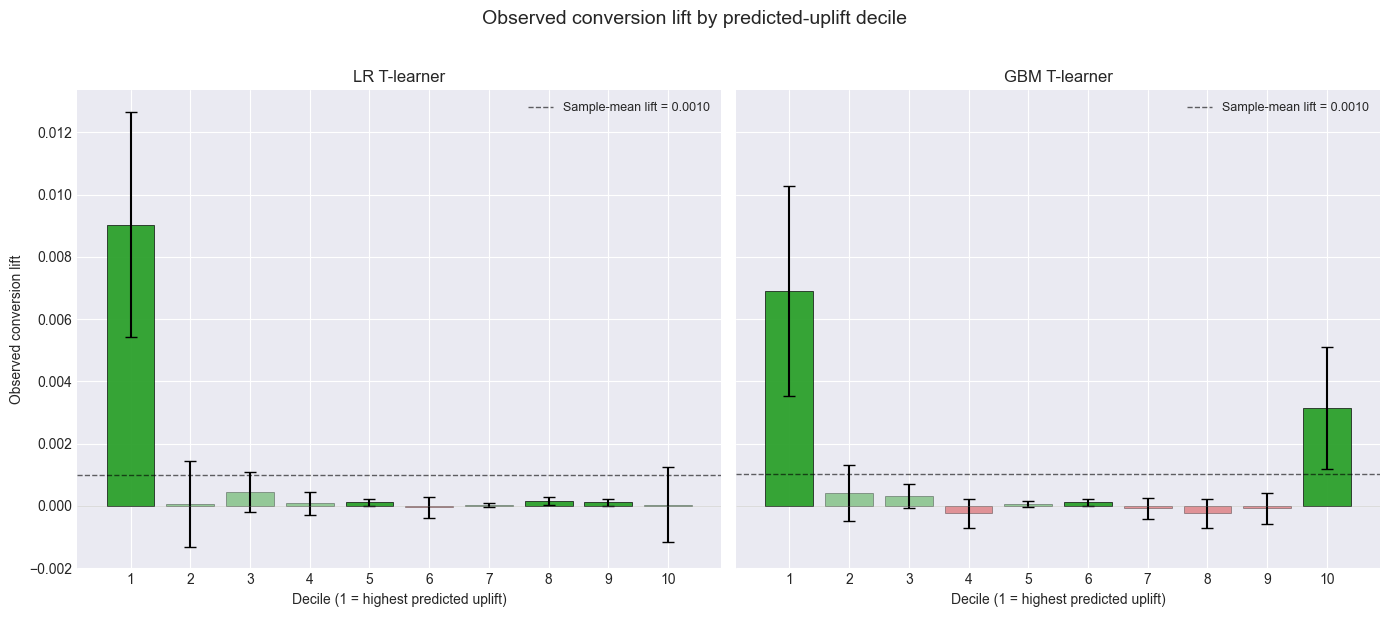

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, (model_name, df) in zip(axes, [("LR T-learner", decile_lr), ("GBM T-learner", decile_gbm)]):
    deciles = df["decile"].values
    lift = df["observed_lift"].values
    err = 1.96 * df["observed_lift_se"].values  # 95% CI

    # Color: green positive, red negative; faded if CI crosses zero
    colors = ["#2ca02c" if v >= 0 else "#d62728" for v in lift]
    alphas = [0.95 if abs(lift[i]) > err[i] else 0.45 for i in range(len(lift))]

    bars = ax.bar(deciles, lift, yerr=err, capsize=4, color=colors,
                  edgecolor="black", linewidth=0.5)
    for bar, a in zip(bars, alphas):
        bar.set_alpha(a)

    # Reference: average lift (= global ATE on this test sample)
    mean_lift = (df["observed_lift"] * df["n"]).sum() / df["n"].sum()
    ax.axhline(mean_lift, linestyle="--", linewidth=1.0, color="black",
               alpha=0.6, label=f"Sample-mean lift = {mean_lift:.4f}")
    ax.axhline(0, linestyle="-", linewidth=0.4, color="gray", alpha=0.5)

    ax.set_xlabel("Decile (1 = highest predicted uplift)")
    ax.set_xticks(deciles)
    if ax is axes[0]:
        ax.set_ylabel("Observed conversion lift")
    ax.set_title(f"{model_name}")
    ax.legend(loc="upper right", fontsize=9)

plt.suptitle("Observed conversion lift by predicted-uplift decile", fontsize=14, y=1.02)
plt.tight_layout()
out_path = FIG_DIR / "decile_lift_chart.png"
plt.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved {out_path}")
plt.show()

In [8]:
def top_vs_bottom_summary(df, model_label):
    top    = df[df.decile == 1].iloc[0]
    bottom = df[df.decile == 10].iloc[0]
    mean_lift = (df["observed_lift"] * df["n"]).sum() / df["n"].sum()

    return {
        "model": model_label,
        "top_decile_lift": float(top["observed_lift"]),
        "bottom_decile_lift": float(bottom["observed_lift"]),
        "ratio": float(top["observed_lift"] / bottom["observed_lift"])
                 if bottom["observed_lift"] not in (0, None) else None,
        "top_vs_mean": float(top["observed_lift"] / mean_lift),
        "sample_mean_lift": float(mean_lift),
        "top_n": int(top["n"]),
        "bottom_n": int(bottom["n"]),
    }

import json
summary = {
    "lr":  top_vs_bottom_summary(decile_lr,  "LR T-learner"),
    "gbm": top_vs_bottom_summary(decile_gbm, "GBM T-learner"),
}
with open(WRITEUP_DIR / "decile_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))

{
  "lr": {
    "model": "LR T-learner",
    "top_decile_lift": 0.00903892394896868,
    "bottom_decile_lift": 4.05936384694312e-05,
    "ratio": 222.66848426941058,
    "top_vs_mean": 9.011862319245637,
    "sample_mean_lift": 0.001003002889831689,
    "top_n": 40000,
    "bottom_n": 40000
  },
  "gbm": {
    "model": "GBM T-learner",
    "top_decile_lift": 0.006892188049486155,
    "bottom_decile_lift": 0.0031387533431349347,
    "ratio": 2.1958361476733157,
    "top_vs_mean": 6.6992490189954905,
    "sample_mean_lift": 0.001028800098330961,
    "top_n": 40000,
    "bottom_n": 40000
  }
}


In [9]:
con.close()
print("Connection closed.")

Connection closed.
